In [24]:
import pandas as pd
df = pd.read_csv("clean_churn_raw.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Part 1 — The Business Problem

1. The telecom company is losing customers to competitors and wants to identify,
in advance, which customers are likely to churn so it can intervene with retention
offers before they leave. As a data problem, this is a binary classification task:
predict whether a customer will churn (Yes/No). The target variable is the Churn column.

2. Useful predictors: Contract, tenure, MonthlyCharges, InternetService, PaymentMethod.
Useless predictors: customerID (unique identifier, no signal), gender (weak relationship with churn).

3. Questions:
- Do churned customers skew toward low tenure, or does churn happen broadly across tenure levels?
- Does having fewer bundled services (OnlineSecurity, TechSupport) correlate with higher churn?

## Part 2 — Exploring the Dataset Structure

In [25]:
import pandas as pd
df = pd.read_csv("clean_churn_raw.csv")

print("Shape:", df.shape)
print(df.dtypes)

numerical_cols = df.select_dtypes(include='number').columns.tolist()
categorical_cols = df.select_dtypes(exclude='number').columns.tolist()
print("Numerical columns:", numerical_cols)
print("Categorical columns:", categorical_cols)

print("customerID unique?", df['customerID'].is_unique)

for col in ['InternetService', 'Contract', 'PaymentMethod']:
    print(col, "->", df[col].unique())

Shape: (7043, 21)
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object
Numerical columns: ['SeniorCitizen', 'tenure', 'MonthlyCharges']
Categorical columns: ['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges', 'Churn']
customerID uniq

- The dataset has 7,043 customers and 21 columns (20 features + target).
- Numerical: SeniorCitizen, tenure, MonthlyCharges. Categorical: the remaining 18
  (including TotalCharges, which is wrongly stored as text).
- customerID is a pure identifier (all unique values). TotalCharges has the wrong
  dtype - it's stored as text because some rows contain blank values.
- InternetService, Contract, and PaymentMethod all show clean, expected categories
  with no typos or inconsistent formatting.

## Part 3 — Investigating Data Quality

In [26]:
print(df.isnull().sum())
print((df.isnull().mean()*100).round(2))

print("Fully duplicated rows:", df.duplicated().sum())
print("Duplicate customerIDs:", df['customerID'].duplicated().sum())

for col in df.columns:
    if df[col].dtype == object:
        vals = df[col].astype(str).str.strip()
        blanks = (vals == '').sum()
        if blanks:
            print(col, "blank strings:", blanks)

bad_rows = df[df['TotalCharges'].astype(str).str.strip() == '']
print(bad_rows[['customerID', 'tenure', 'TotalCharges']])

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64
customerID          0.0
gender              0.0
SeniorCitizen       0.0
Partner             0.0
Dependents          0.0
tenure              0.0
PhoneService        0.0
MultipleLines       0.0
InternetService     0.0
OnlineSecurity      0.0
OnlineBackup        0.0
DeviceProtection    0.0
TechSupport         0.0
StreamingTV         0.0
StreamingMovies     0.0
Contract            0.0
PaperlessBilling    0.0
PaymentMethod       0.0
MonthlyCharges      0.0
TotalCharges        0.0
Churn               0.0
dtype: float64
Fully 

- df.isnull().sum() shows 0 missing values everywhere - but this is misleading.
  The "missing" values in this dataset are stored as blank strings, not NaN.
- Scanning for blank strings reveals 11 rows (0.16%) with a blank TotalCharges.
  This is small enough to not seriously affect the dataset.
- No duplicate rows and no duplicate customerIDs - verified, not assumed.
- The 11 blank TotalCharges rows all have tenure == 0, meaning these are brand-new
  customers who haven't been billed yet - a logical explanation, not corrupted data.

## Part 4 — Data Cleaning Decisions

| Problem | Decision | Method | Reason |
|---|---|---|---|
| TotalCharges stored as text, 11 blanks | Convert to numeric, fill blanks with 0 | pd.to_numeric + fillna(0) | Blanks correspond to tenure=0, so 0 is the correct value, not a guess |
| SeniorCitizen stored as 0/1 | Recode to Yes/No | .map({0:'No',1:'Yes'}) | It's conceptually categorical, not continuous |
| Duplicate rows/IDs | No action needed | Verified via .duplicated() | Confirmed none exist |

In [27]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(0)

df['SeniorCitizen'] = df['SeniorCitizen'].map({0: 'No', 1: 'Yes'})

print(df['TotalCharges'].dtype)
print(df['TotalCharges'].isnull().sum())
print(df['SeniorCitizen'].unique())

float64
0
['No' 'Yes']


## Part 5 — Univariate EDA

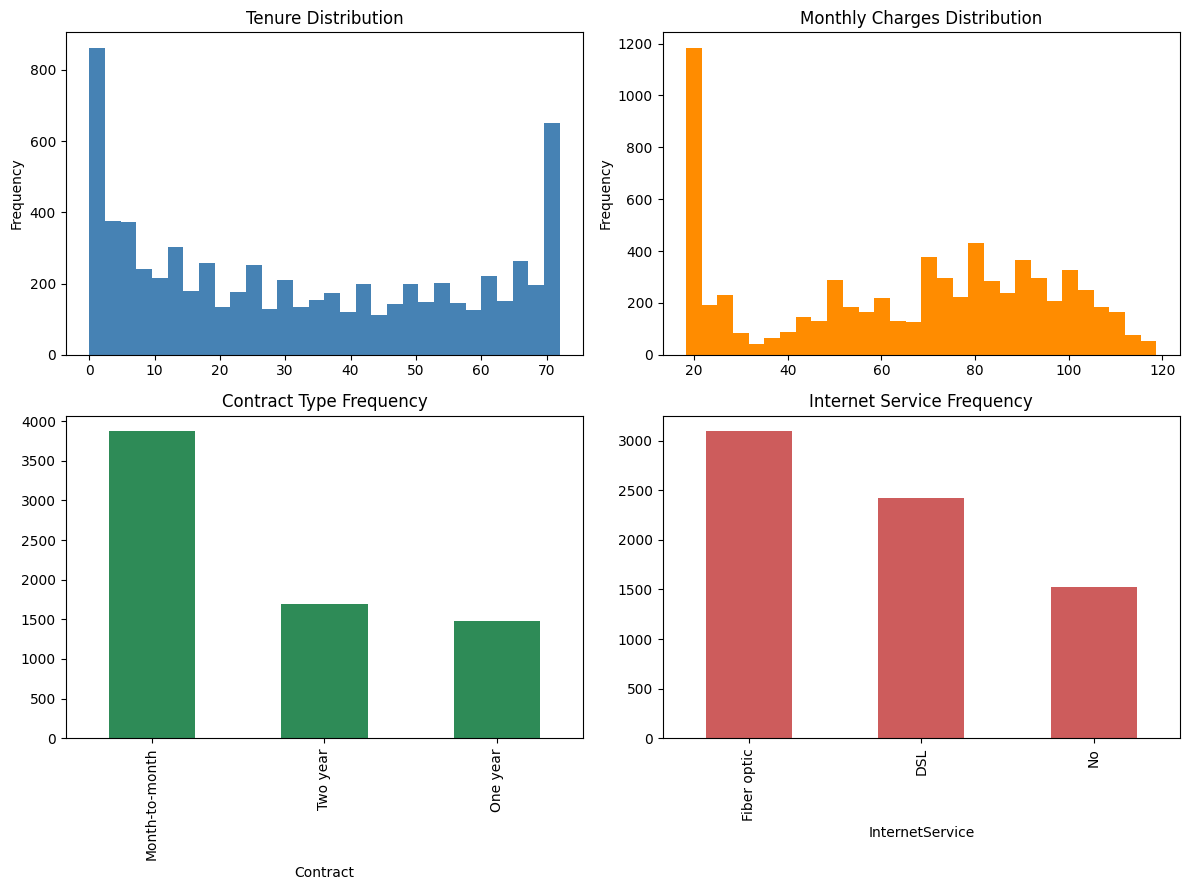

tenure skew: 0.2395397495619829
MonthlyCharges skew: -0.22052443394398033
TotalCharges skew: 0.963234654832277


In [28]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(12,9))

df['tenure'].plot(kind='hist', bins=30, ax=axes[0,0], color='steelblue')
axes[0,0].set_title('Tenure Distribution')

df['MonthlyCharges'].plot(kind='hist', bins=30, ax=axes[0,1], color='darkorange')
axes[0,1].set_title('Monthly Charges Distribution')

df['Contract'].value_counts().plot(kind='bar', ax=axes[1,0], color='seagreen')
axes[1,0].set_title('Contract Type Frequency')

df['InternetService'].value_counts().plot(kind='bar', ax=axes[1,1], color='indianred')
axes[1,1].set_title('Internet Service Frequency')

plt.tight_layout()
plt.show()

print("tenure skew:", df['tenure'].skew())
print("MonthlyCharges skew:", df['MonthlyCharges'].skew())
print("TotalCharges skew:", df['TotalCharges'].skew())

- Tenure is bimodal: a spike near 0 months and another near 70+ months, with fewer
  customers in between.
- MonthlyCharges has a sharp spike near $20 (customers with only phone service),
  then spreads fairly evenly between $40-$110.
- Contract is heavily skewed toward Month-to-month (3,875 customers).
- Fiber optic is the most common internet service (3,096), ahead of DSL (2,421)
  and No internet (1,526).
- TotalCharges is the most skewed feature (skew ~0.96) because it accumulates over
  tenure - but this isn't a data problem, it's a natural consequence of billing.

## Part 6 — Target Variable Analysis

In [29]:
print(df['Churn'].value_counts())
print((df['Churn'].value_counts(normalize=True)*100).round(2))

Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64


- No churn: 5,174 (73.46%), Churn: 1,869 (26.54%) - the target is imbalanced.
- This matters because a model could get high accuracy just by predicting "No" for
  everyone, without learning to identify actual churn risk. Metrics like precision/
  recall on the churn class matter more than plain accuracy here.

## Part 7 — Bivariate Analysis: Features vs. Churn

Churn                  No        Yes
Contract                            
Month-to-month  57.290323  42.709677
One year        88.730482  11.269518
Two year        97.168142   2.831858
Churn                             No        Yes
PaymentMethod                                  
Bank transfer (automatic)  83.290155  16.709845
Credit card (automatic)    84.756899  15.243101
Electronic check           54.714588  45.285412
Mailed check               80.893300  19.106700
        count       mean        std  min   25%   50%   75%   max
Churn                                                           
No     5174.0  37.569965  24.113777  0.0  15.0  38.0  61.0  72.0
Yes    1869.0  17.979133  19.531123  1.0   2.0  10.0  29.0  72.0
        count       mean        std    min    25%     50%   75%     max
Churn                                                                  
No     5174.0  61.265124  31.092648  18.25  25.10  64.425  88.4  118.75
Yes    1869.0  74.441332  24.666053  18.85  56.15  

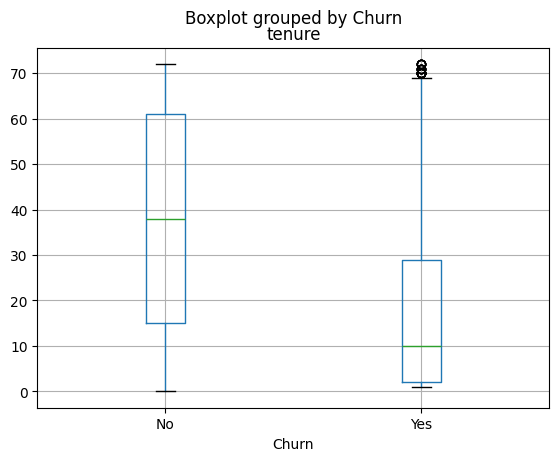

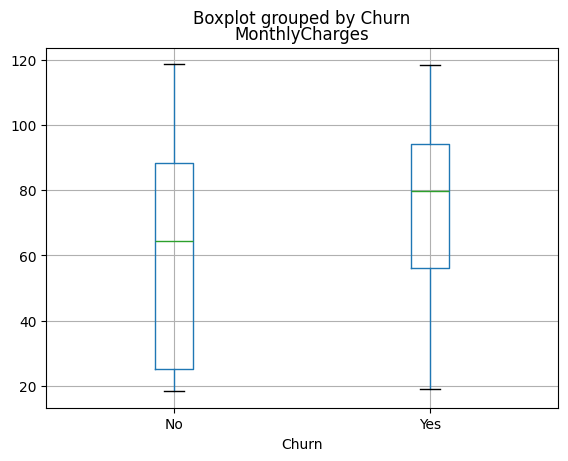

In [30]:
print(pd.crosstab(df['Contract'], df['Churn'], normalize='index')*100)
print(pd.crosstab(df['PaymentMethod'], df['Churn'], normalize='index')*100)

print(df.groupby('Churn')['tenure'].describe())
print(df.groupby('Churn')['MonthlyCharges'].describe())

df.boxplot(column='tenure', by='Churn')
plt.show()

df.boxplot(column='MonthlyCharges', by='Churn')
plt.show()

- Contract: Month-to-month churn = 42.71%, One year = 11.27%, Two year = 2.83%.
  Longer contracts strongly reduce churn.
- PaymentMethod: Electronic check churn = 45.29%, vs 15-20% for other methods.
  Auto-pay customers churn much less.
- tenure: churners have median tenure of 10 months vs 38 for non-churners - churn
  happens early.
- MonthlyCharges: churners pay more on average ($79.65 median vs $64.43) - possibly
  more price-sensitive.

## Part 8 — Correlation & Feature Relationships

                tenure  MonthlyCharges  TotalCharges
tenure           1.000           0.248         0.826
MonthlyCharges   0.248           1.000         0.651
TotalCharges     0.826           0.651         1.000


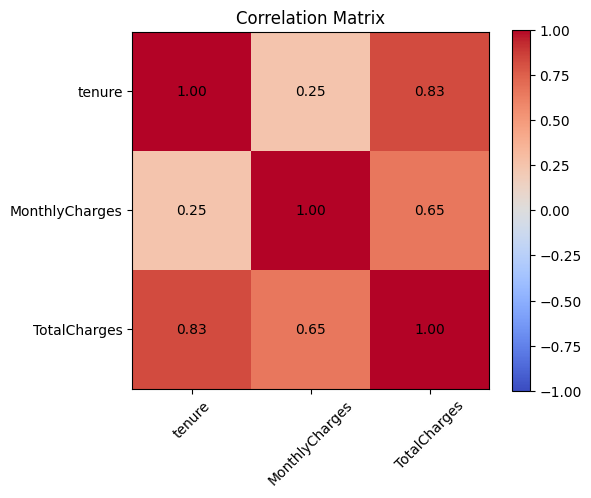

In [31]:
corr = df.corr(numeric_only=True)
print(corr.round(3))

plt.figure(figsize=(6,5))
plt.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)
for i in range(len(corr)):
    for j in range(len(corr)):
        plt.text(j, i, f"{corr.iloc[i,j]:.2f}", ha='center', va='center')
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

- tenure and TotalCharges are most correlated (r=0.83), followed by MonthlyCharges
  and TotalCharges (r=0.65).
- Correlation doesn't imply causation - TotalCharges is mathematically derived from
  tenure and billing, not causally related. This is redundancy, and including both
  could cause multicollinearity issues in a future model.

## Part 9 — Data Leakage Awareness

- customerID: pure identifier, no predictive value, should be removed.
- tenure (and TotalCharges by extension): for churned customers, tenure basically
  equals "months until they left" - this is tied to the outcome itself, making it a
  leakage risk.
- If left in without care, the model would look highly accurate in testing but fail
  in real deployment, since a real active customer's "final" tenure isn't known in
  advance. This gives false confidence in a model that can't generalize.

## Part 10 — ML-Readiness Checklist

| Column | Type | Role | Action | Reason |
|---|---|---|---|---|
| customerID | Identifier | — | Remove | No predictive value |
| gender | Categorical | Feature | Keep | Weak relationship with churn |
| SeniorCitizen | Categorical | Feature | Keep, recode | Binary category, not numeric |
| Partner | Categorical | Feature | Keep | May relate to service stability |
| Dependents | Categorical | Feature | Keep | Similar to Partner |
| tenure | Numerical | Feature (caution) | Keep, flag | Leakage risk |
| PhoneService | Categorical | Feature | Keep | Base service context |
| MultipleLines | Categorical | Feature | Keep | Valid categories, no missing |
| InternetService | Categorical | Feature | Keep | Strong churn signal |
| OnlineSecurity | Categorical | Feature | Keep | Valid categories |
| OnlineBackup | Categorical | Feature | Keep | Valid categories |
| DeviceProtection | Categorical | Feature | Keep | Valid categories |
| TechSupport | Categorical | Feature | Keep | Valid categories |
| StreamingTV | Categorical | Feature | Keep | Valid categories |
| StreamingMovies | Categorical | Feature | Keep | Valid categories |
| Contract | Categorical | Feature | Keep | Strongest churn predictor |
| PaperlessBilling | Categorical | Feature | Keep | Minor signal |
| PaymentMethod | Categorical | Feature | Keep | Strong churn signal |
| MonthlyCharges | Numerical | Feature | Keep | Moderate churn signal |
| TotalCharges | Numerical | Feature (caution) | Fix dtype, fill, flag | Correlated with tenure |
| Churn | Categorical | Target | Keep | Prediction target |

## Part 11 — Building the Clean Dataset

In [32]:
clean_df = df.drop(columns=['customerID'])

print(clean_df.info())
print(clean_df.isnull().sum())
print("Duplicates:", clean_df.duplicated().sum())

clean_df.to_csv("clean_churn.csv", index=False)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   object 
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


## Part 12 — Key Findings & Final Reflection

Five Key Findings:

1. Observation: Contract type is the strongest churn driver.
   Evidence: Month-to-month = 42.71% churn, Two year = 2.83%.
   Interpretation: No lock-in dramatically increases churn risk.

2. Observation: New customers churn more than long-tenured ones.
   Evidence: Median tenure 10 months (churn) vs 38 months (no churn).
   Interpretation: Churn risk is concentrated early in the customer lifecycle.

3. Observation: Payment method correlates with churn.
   Evidence: Electronic check = 45.29% churn vs 15-20% for auto-pay methods.
   Interpretation: Manual payment may signal lower engagement/stickiness.

4. Observation: Hidden missing values in TotalCharges.
   Evidence: 11 blank strings (not NaN), all with tenure=0.
   Interpretation: Missingness was structural, not random - new customers with no
   billing history yet.

5. Observation: tenure and TotalCharges are highly correlated and both risk leakage.
   Evidence: r=0.83; tenure ~ "months until churn" for churned customers.
   Interpretation: These features are redundant and need careful handling in Lab 3.

Final Reflection:
1. Most important data-quality issue: hidden blank TotalCharges values.
2. Most interesting pattern: Contract's huge effect on churn rate.
3. Most useful feature: Contract.
4. Feature to be careful with: tenure (leakage risk).
5. Preprocessing needed: encode categoricals, scale numerics, fix tenure/TotalCharges
   redundancy, handle class imbalance.
6. With 3 more hours: explore feature interactions (e.g. Fiber optic + Electronic
   check), and investigate the "no internet service" subgroup further.